In [8]:
import os
import numpy as np
import h5py
import random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from pytorch_lightning import LightningModule
from sklearn.model_selection import train_test_split

In [9]:
# Path setup
model_path = "best_model_v14-RadFullMSE---epoch=7161-val_loss=0.00082880.ckpt"  
garstec_data = r'C:\Users\kiena\Documents\YEAR 4\PROJECT\Data\Garstec_AS09_chiara.hdf5'
save_dir = r'C:\Users\kiena\Python Project\Year4Project\dev\GarstecModel_V9' 
os.makedirs(save_dir, exist_ok=True)

In [10]:
# Lightning Module
class GarstecNet(LightningModule):
    def __init__(self, input_dim, output_dim, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        # Define MSE loss
        self.loss_fn = nn.MSELoss()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),  # First layer
            nn.LeakyReLU(),
            nn.Linear(256, 256),  # Second layer
            nn.LeakyReLU(),
            nn.Linear(256, 128),  # Third layer
            nn.LeakyReLU(),
            nn.Linear(128, 128),  # Fourth layer
            nn.LeakyReLU(),
            nn.Linear(128, output_dim)  # Output layer
        )

    def forward(self, x):
        return self.model(x)

In [10]:
# Single

def load_data():
    # 7 Inputs
    ages = []
    massini = []
    fehini = []
    alphamlt = []
    yini = []
    eta = []
    alphafe = []

    # 1 Output (only radius)
    radius = []

    # Open the hdf5 file (read-only mode)
    with h5py.File(garstec_data, 'r') as hdf:
        grid = hdf['grid']
        tracks = grid['tracks']

        # Get a list of track names and shuffle for random sampling
        track_names = list(tracks.keys())
        random.seed(1)
        random.shuffle(track_names)

        # Choose a subset of tracks to process (or not)
        selected_tracks = track_names[:]

        # Track which points belong to which tracks
        track_indices = []

        for track_name in selected_tracks:  # Iterate over the selected track names
            track = tracks[track_name]
            # Inputs
            ages.append(track['age'][:])
            massini.append(track['massini'][:])
            fehini.append(track['FeHini'][:])
            alphamlt.append(track['alphaMLT'][:])
            yini.append(track['yini'][:])
            eta.append(track['eta'][:])
            alphafe.append(track['alphaFe'][:])
                                                                                                    
            # Output (only radius)
            radius.append(track['radPhot'][:])

            # Add the track index for each point in this track
            track_indices.extend([len(track_indices)] * len(track['radPhot'][:]))

    # Convert lists to numpy arrays and concatenate 
    # Define a small constant to avoid log10(0)
    epsilon = 1e-10

    # Features requiring log10 transformation
    log10_vars_inputs = [ages, yini]  # Removed massini, alphamlt, and eta

    # Transform log10 variables
    log10_transformed_inputs = [np.log10(np.maximum(np.concatenate(var).reshape(-1, 1), epsilon)) for var in log10_vars_inputs]

    # Concatenate all inputs
    inputs = np.hstack(log10_transformed_inputs + [
        np.concatenate(massini).reshape(-1, 1),       # Raw massini
        np.concatenate(alphamlt).reshape(-1, 1),      # Raw alphamlt
        np.concatenate(eta).reshape(-1, 1),           # Raw eta
        np.concatenate(fehini).reshape(-1, 1),
        np.concatenate(alphafe).reshape(-1, 1)
    ])

    # Output - radius (no log10 transformation)
    outputs = np.concatenate(radius).reshape(-1, 1)

    output_names = ['Radius']

    return inputs, outputs, output_names, track_indices


In [11]:
# Full

def load_data():
    # 7 Inputs
    ages = []
    massini = []
    fehini = []
    alphamlt = []
    yini = []
    eta = []
    alphafe = []

    # 5 Outputs (replaced luminosity with radius)
    teff = []
    radius = []  # Using radius instead of luminosity
    dnufit = []
    FeH = []
    numax = []

    # Open the hdf5 file (read-only mode)
    with h5py.File(garstec_data, 'r') as hdf:
        grid = hdf['grid']
        tracks = grid['tracks']

        # Get a list of track names and shuffle for random sampling
        track_names = list(tracks.keys())
        random.seed(1)
        random.shuffle(track_names)

        # Choose a subset of tracks to process (or not)
        selected_tracks = track_names[:]

        # Track which points belong to which tracks
        track_indices = []

        for track_name in selected_tracks:  # Iterate over the selected track names
            track = tracks[track_name]
            # Inputs
            ages.append(track['age'][:])
            massini.append(track['massini'][:])
            fehini.append(track['FeHini'][:])
            alphamlt.append(track['alphaMLT'][:])
            yini.append(track['yini'][:])
            eta.append(track['eta'][:])
            alphafe.append(track['alphaFe'][:])

            # Outputs (replaced LPhot with radPhot)
            teff.append(track['Teff'][:])
            radius.append(track['radPhot'][:])  # Replaced luminosity with radius
            dnufit.append(track['dnufit'][:])
            FeH.append(track['FeH'][:])
            numax.append(track['numax'][:])

            # Add the track index for each point in this track
            track_indices.extend([len(track_indices)] * len(track['radPhot'][:]))

    # Convert lists to numpy arrays and concatenate 
    # Define a small constant to avoid log10(0)
    epsilon = 1e-10

    # Features requiring log10 transformation - MODIFIED to exclude eta, massini, and alphamlt
    log10_vars_inputs = [ages, yini]  # Removed massini, alphamlt, and eta

    # Transform log10 variables
    log10_transformed_inputs = [np.log10(np.maximum(np.concatenate(var).reshape(-1, 1), epsilon)) for var in log10_vars_inputs]

    # Concatenate all inputs, including raw `fehini` and `yini`
    inputs = np.hstack(log10_transformed_inputs + [
        np.concatenate(massini).reshape(-1, 1),       # Raw massini
        np.concatenate(alphamlt).reshape(-1, 1),      # Raw alphamlt
        np.concatenate(eta).reshape(-1, 1),           # Raw eta
        np.concatenate(fehini).reshape(-1, 1),
        np.concatenate(alphafe).reshape(-1, 1)
    ])

    # Features requiring log10 transformation (strictly positive outputs)
    log10_vars_outputs = [teff, dnufit, numax]  # Removed luminosity

    # Transform log10 variables
    log10_transformed_outputs = [np.log10(np.maximum(np.concatenate(var).reshape(-1, 1), epsilon)) for var in log10_vars_outputs]

    # Get radius (no log10 transformation)
    radius_data = np.concatenate(radius).reshape(-1, 1)

    # Combine transformed log10 outputs with raw FeH and radius
    outputs = np.hstack(log10_transformed_outputs + [
        np.concatenate(FeH).reshape(-1, 1),
        radius_data  # Added radius (not log10 transformed)
    ])

    output_names = ['T_eff', 'dnu', 'numax', 'FeH', 'Radius']

    return inputs, outputs, output_names, track_indices


In [12]:
# Calculate residuals

# Check for CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load data
inputs, outputs, output_names, track_indices = load_data()  # Radius is the only output

# Split data
X_train, X_test, y_train, y_test = train_test_split(inputs, outputs, test_size=0.2, random_state=1)

# Scale data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)


Using device: cuda


In [13]:
# Load trained model
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

print("Input dim: ",input_dim)
print("Output dim: ",output_dim)

model = GarstecNet.load_from_checkpoint(
    model_path,
    input_dim=input_dim,
    output_dim=output_dim,
    map_location=device
)
model.eval()
model.to(device)

# Make predictions
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred = model(X_test_tensor).cpu().numpy()

# Inverse transform predictions
y_pred_original = scaler_y.inverse_transform(y_pred)
y_test_original = scaler_y.inverse_transform(y_test)

# Calculate residuals
log_residuals = y_pred_original - y_test_original  

# For log-transformed variables (columns 0, 1, 2), convert back to linear space
for col in [0, 1, 2]:  # T_eff, dnu, numax
    y_pred_original[:, col] = 10**y_pred_original[:, col]
    y_test_original[:, col] = 10**y_test_original[:, col]

# Then calculate residuals in original units
normal_residuals = y_pred_original - y_test_original

Input dim:  7
Output dim:  5


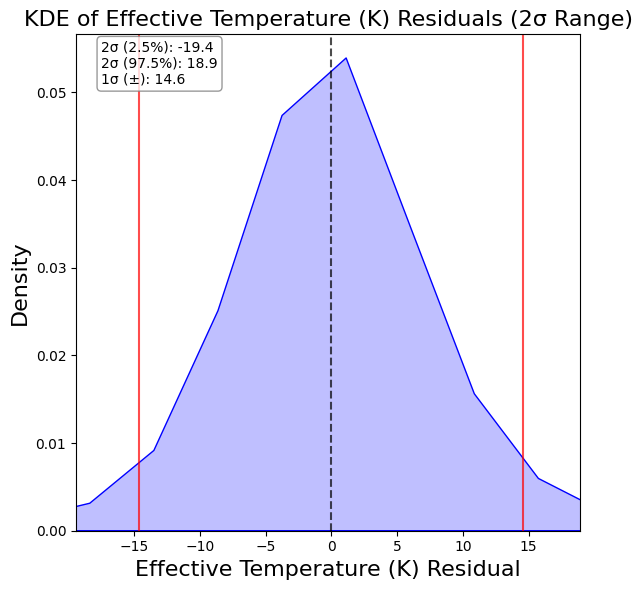

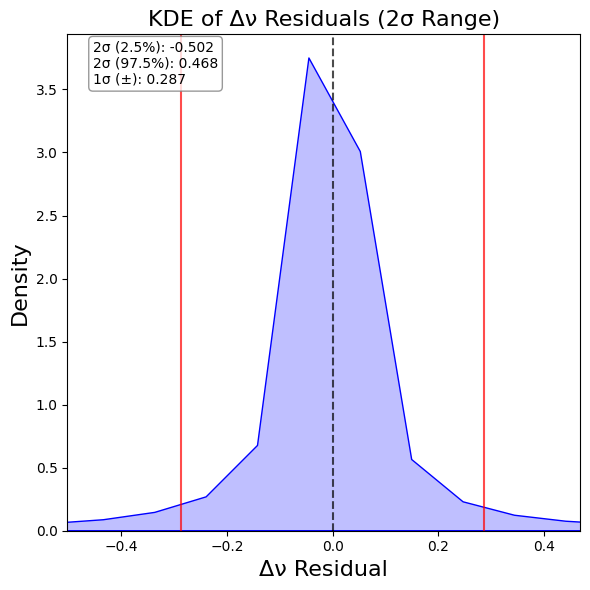

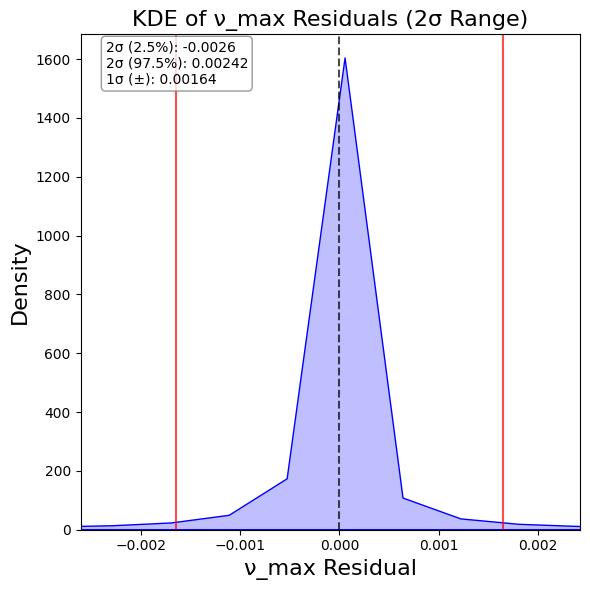

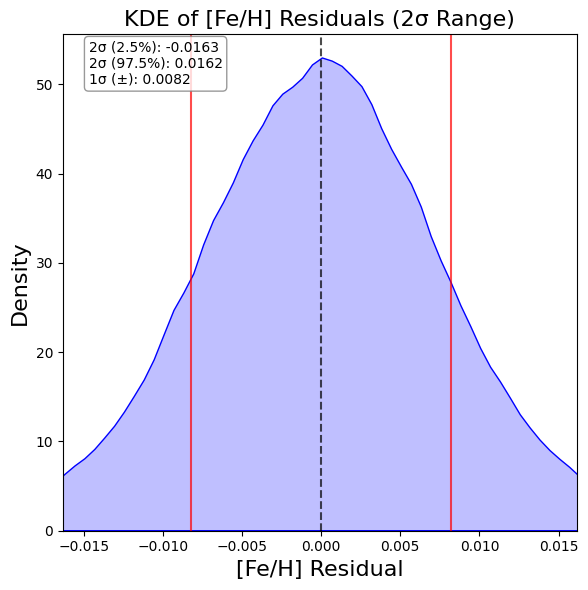

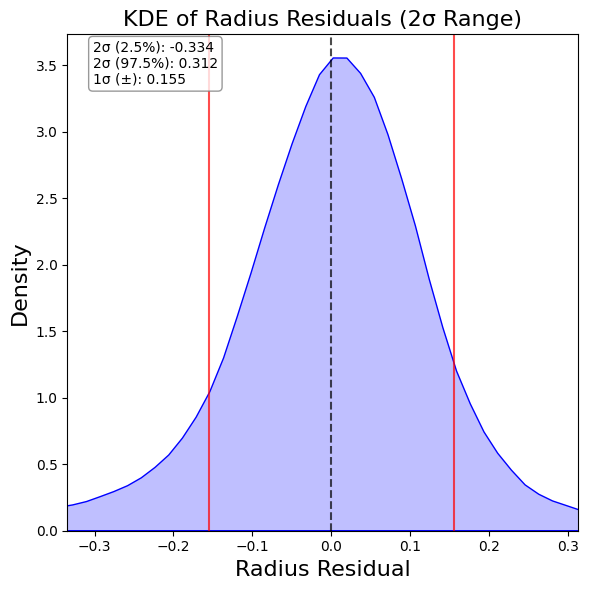

In [14]:
def individual_kde_plots():
    # Define parameter names for each column of normal_residuals
    names = ["Effective Temperature (K)", "Δν", "ν_max", "[Fe/H]", "Radius"]
    
    # Iterate through each parameter
    for i, name in enumerate(names):
        # Extract residuals for current parameter
        residual = normal_residuals[:, i]
        
        # Calculate the standard deviation
        std_dev = np.std(residual)
        
        # Calculate the 2.5th and 97.5th percentiles (2-sigma, 95%)
        lower_bound = np.percentile(residual, 2.5)
        upper_bound = np.percentile(residual, 97.5)
        
        plt.figure(figsize=(6, 6))
        
        # Create KDE plot
        sns.kdeplot(x=residual, fill=True, color='blue')
        
        # Add reference line at zero
        plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
        
        # Add lines for ±1 standard deviation
        plt.axvline(x=std_dev, color='red', linestyle='-', alpha=0.7)
        plt.axvline(x=-std_dev, color='red', linestyle='-', alpha=0.7)
        
        # Set x-axis limits to show 2-sigma range
        plt.xlim(lower_bound, upper_bound)
        
        # Add title and labels
        plt.title(f'KDE of {name} Residuals (2σ Range)', fontsize=16)
        plt.xlabel(f'{name} Residual', fontsize=16)
        plt.ylabel('Density', fontsize=16)
        
        # Function to format numbers with 3 significant figures
        def format_sig_figs(x, sig_figs=3):
            return f"{x:.{sig_figs}g}"
        
        # Display percentile and standard deviation values in a text box with 3 significant figures
        plt.annotate(f'2σ (2.5%): {format_sig_figs(lower_bound)}\n'
                     f'2σ (97.5%): {format_sig_figs(upper_bound)}\n'
                     f'1σ (±): {format_sig_figs(std_dev)}', 
                    xy=(0.05, 0.9), xycoords='axes fraction',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
        
        plt.tight_layout()
        plt.show()

individual_kde_plots()